# Load MMS data

In [262]:
# from pathlib import Path
# import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import pyspedas
# import cdflib
from IPython.display import display, Latex

# Local MMS data storage
# DATA_DIR = Path("/Users/christylentz/MMS_data")
# DATA_DIR.mkdir(parents=True, exist_ok=True)

# # Tell PySPEDAS where to cache files
# os.environ["SPEDAS_DATA_DIR"] = str(DATA_DIR)

# print(DATA_DIR)

In [263]:
probe = "2"
titles =[f'MMS{probe}']


# #Constants
c = 2.99792458e8  #speed of light (m/s)
m_e = 9.10939e-31         #electron mass (kg)
eps0 = 8.8541878e-12  #epsilon (As/Vm)
e = 1.6022e-19         #charge (C=As)
my = 4.0*1e-7     #my0 (Vs/Am)
mp = 1.672623*1e-27    #proton rest mass  (kg)
kb = 1.38066*1e-23     #Boltzmann constant (J/K) (kg m^2 s^-2)(K^-1)
μ0 = 1.256637061*1e-6 # N A^-2 #kg m s^-2 A^-2


saveDIR ='/Users/christylentz/iCloud/LASP-MacL4326/MMS/KH_project/Resubmission_V2/'
opp = None
#dtref = 2.0
h2 = None
suffix = None
dverr = []
utc = [] #strarr(ntmax)


# Event Descriptions

In [264]:

# Event start and stop times might be different than CS start and stop times. Event = CS and full reconnection exhaust. 
# Trying to get the cleanest LMN by using specific CS st/stop times



# event_num = 'other events'
# #event_st_stop =['2020-06-17/21:16:45.000','2020-06-17/21:17:30.000'] #3 
# event_st_stop =['2020-06-17/21:11:26.000','2020-06-17/21:11:48.000'] #3 
# CS_st_stop_t = ['2020-06-17/21:11:26.000','2020-06-17/21:11:48.000']
# t1 = ['2020-06-17 21:11:26.000']
# t2 = ['2020-06-17 21:11:48.000']
# trange =['2020-06-17/21:09:00','2020-06-17/21:19:00']

# # times used to compute LMN coordinates
# m1 = pd.to_datetime(CS_st_stop_t[0])
# m2 = pd.to_datetime(CS_st_stop_t[1])




# ######################################  
# # Leading Edge
# ###################################### 
# event_num = 'Event 1'
# event_st_stop =['2020-06-17/21:16:54.900','2020-06-17/21:17:07.000']
# CS_st_stop_t = ['2020-06-17/21:16:54.900','2020-06-17/21:17:07.000']
# trange =['2020-06-17/21:16:00','2020-06-17/21:18:00']


######################################  
# Trailing Edge
###################################### 
# event_num = 'Event 2'
# event_st_stop =['2020-06-17/21:24:36.000','2020-06-17/21:25:20.000'] 
# trange =['2020-06-17/21:20:00','2020-06-17/21:30:00']
# CS_st_stop_t = ['2020-06-17/21:24:36.000','2020-06-17/21:25:20.000'] 

######################################  
# Trailing Edge
###################################### 

# event_num = 'Event 3'
# event_st_stop =['2020-06-17/21:40:51.400','2020-06-17/21:41:20.799']
# trange =['2020-06-17/21:40:00','2020-06-17/21:42:00']
# CS_st_stop_t = ['2020-06-17/21:40:50.5555','2020-06-17/21:41:21.5403']



######################################  
# Leading Edge
###################################### 
# event_num = 'Event 4'
# event_st_stop =['2020-06-17/22:18:18.200','2020-06-17/22:18:31.000']
# trange =['2020-06-17/22:15:00','2020-06-17/22:20:00']
# CS_st_stop_t = ['2020-06-17 22:18:17','2020-06-17 22:18:25']

######################################  
# Trailing Edge
###################################### \
# event_num = 'Event 5'
# event_st_stop = CS_st_stop_t =['2020-06-17/22:43:34.000','2020-06-17/22:44:03.599']
# trange =['2020-06-17/22:42:00','2020-06-17/22:45:00']

######################################  
# Leading Edge
###################################### 
# event_num = 'Event 6'
# event_st_stop =['2020-06-17/22:46:25.250','2020-06-17/22:46:38.500']
# CS_st_stop_t = ['2020-06-17/22:46:25.250','2020-06-17/22:46:38.500']
# trange =['2020-06-17/22:45:00','2020-06-17/22:48:00']

######################################  
# Trailing Edge
###################################### 
# event_num = 'Event 7'
# event_st_stop =CS_st_stop_t =['2020-06-17/23:03:50.000','2020-06-17/23:03:58.000'] 
# trange =['2020-06-17/23:02:00','2020-06-17/23:05:00']

######################################  
# Undefined
###################################### 
# event_num = 'Event 8'
# event_st_stop =['2020-06-17 23:10:43.000','2020-06-17 23:10:52.000']
# CS_st_stop_t = ['2020-06-17 23:10:43.000','2020-06-17 23:10:52.000']
# trange =['2020-06-17/23:09:00','2020-06-17/23:12:00']


# ######################################  
# # Leading Edge
# ###################################### 
# event_num = 'Event 9'
# trange =['2020-06-17/23:16:00','2020-06-17/23:19:00']
# event_st_stop =['2020-06-17/23:17:17.299','2020-06-17/23:17:28.000']
# CS_st_stop_t = ['2020-06-17/23:17:17.299','2020-06-17/23:17:28.000']

######################################  
# Leading Edge
# ###################################### 
# event_num = 'Event 10'
# trange =['2020-06-17/23:30:00','2020-06-17/23:40:00']
# event_st_stop =['2020-06-17 23:34:55.400','2020-06-17 23:35:17.500']
# CS_st_stop_t = ['2020-06-17 23:34:55.400','2020-06-17 23:35:17.500']



# ######################################  
# Trailing Edge
###################################### 
# event_num = 'Event 11'
# trange = ['2020-06-17/23:41:00','2020-06-17/23:44:00']
# event_st_stop =['2020-06-17/23:42:47.000','2020-06-17/23:42:59.000']
# CS_st_stop_t = ['2020-06-17/23:42:47.000','2020-06-17/23:42:59.000']


# ######################################  
# Leading Edge
###################################### 
# event_num = 'Event 12'
# event_st_stop =CS_st_stop_t =['2020-06-17/23:49:26.400','2020-06-17/23:49:46.350'] #18
# trange =['2020-06-17/23:48:00','2020-06-17/23:51:00']


######################################  
# Trailing Edge
###################################### 
# event_num = 'Event 13'
# event_st_stop =CS_st_stop_t =['2020-06-17/23:57:57.599','2020-06-17/23:58:25.000'] #19
# trange =['2020-06-17/23:56:00','2020-06-17/23:59:00']

######################################  
# Undefined
###################################### 
# event_num = 'Event 14'
# event_st_stop =CS_st_stop_t =['2020-06-18/00:09:41.000','2020-06-18/00:10:05.000'] #21
# trange =['2020-06-18/00:08:00','2020-06-18/00:11:00']

######################################  
# Trailing Edge
###################################### 
event_num = 'Event 15'
event_st_stop =CS_st_stop_t=['2020-06-18/00:22:14.000','2020-06-18/00:22:35.599'] #22
trange =['2020-06-18/00:21:00','2020-06-18/00:23:00']


# Helper Functions

## Minimum Variance Analysis

In [265]:
from numpy import linalg as LA
# #########################
# #GET MAGNETIC FIELD DATA#
# #########################
def mms_mvab(m1,m2,mag_arr_str):
    m1 = pd.to_datetime(m1)
    m2 = pd.to_datetime(m2)
    # ##########################################################
    # Check for NaN values
    NaNs = mag_arr.isnull().values.any()
    if NaNs == True:
        print,'Nans were found: '
        print, mag_arr.isnull().values.any()
        print,'Replacing with average of surrounding data pts '
        # Indices of NaNs in each component
        NaNs_Bx = np.argwhere(np.isnan(bx))
        NaNs_By = np.argwhere(np.isnan(by))
        NaNs_Bz = np.argwhere(np.isnan(bz))

        # If there are NaNs, replace with the average of surrounding couple of data points
        for i in range(len(NaNs_Bx)):
            bx[NaNs_Bx[i]] = np.nanmean(bx[NaNs_Bx[i-3]:NaNs_Bx[i+3]])
            by[NaNs_By[i]] = np.nanmean(by[NaNs_By[i-3]:NaNs_By[i+3]])
            bz[NaNs_Bz[i]] = np.nanmean(bz[NaNs_Bz[i-3]:NaNs_Bz[i+3]])                           
    time = np.array(mag_arr['times'])
    bx = np.array(pd.to_numeric(mag_arr['Bx']))
    by = np.array(pd.to_numeric(mag_arr['By']))
    bz = np.array(pd.to_numeric(mag_arr['Bz']))
    n1 = mag_arr.date[0]
    n2 = mag_arr.date[len(mag_arr.date)-1]
    if m1 < n1:
        print('WARNING!!! start time of current sheet =',m1, 'start time of B-field data =', n1)
    if m1 > n2:
        print('WARNING!!! start time of current sheet =',m1,'end time of B-field data =',n2)
    if m2 > n2:
        print('WARNING!!! end time of current sheet =',m2,'end time of B-field data =',n2)
    if m2 < n1:
        print('WARNING!!! end time of current sheet =',m2,'start time of B-field data =',n1)
    v1 = mag_arr.date.searchsorted(m1)
    v2 = mag_arr.date.searchsorted(m2)
    bx = bx[v1:v2]
    by = by[v1:v2]
    bz = bz[v1:v2]
    
    
    # create the minimum variance matrix. 
    mm = np.zeros([3, 3])
    bxa = np.mean(bx)
    bya = np.mean(by)
    bza = np.mean(bz)
    mm[0,0] = np.mean(bx*bx) - bxa*bxa
    mm[1,0] = np.mean(bx*by) - bxa*bya
    mm[2,0] = np.mean(bx*bz) - bxa*bza
    mm[0,1] = mm[1,0]
    mm[1,1] = np.mean(by*by) - bya*bya
    mm[2,1] = np.mean(by*bz) - bya*bza
    mm[0,2] = mm[2,0]
    mm[1,2] = mm[2,1]
    mm[2,2] = np.mean(bz*bz) - bza*bza
    
# The 3 eigenvectors represent directions of maximum, intermediate, and minimum variance of the field component along each vector. 

# The corresponding eigenvalues (λ) represent the actual variances in those field components & are non-negative 

# The eigenvector x3 (corresponding to the smallest eigenvalue λ3) is used as the estimator for the vector normal to the current sheet.

# λ3 represents the variance of the magnetic field component along the estimated normal. 

# The eigenvectors x1 and x2, corresponding to maximum and intermediate variance are tangential to the transition layer

# eigen vectors should be in GSE coordinate system right?
    eigenvalues, eigenvectors = LA.eig(mm)    
    idx = np.argsort(eigenvalues)
    E_vals_sorted = eigenvalues[idx]
    E_vec_sorted = eigenvectors[:,idx]

    return E_vals_sorted,E_vec_sorted


## Cross-Product Normal

In [266]:
def Cross_product_normal(E_vals,E_vec,m1,m2,mag_arr_str): 
    # mag_arr = pd.read_csv(mag_arr_str,header = 0,names = ['times','Bx','By','Bz','Bmag','date'],
    #                      parse_dates=['date'])
    m1 = pd.to_datetime(m1)
    m2 = pd.to_datetime(m2)
    # lv,mv,nv are in the same coordinate system as the eigenvectors (GSE)
    nv = E_vec[:,0] # take B1 x B2/|B1 x B2|

    #nv = [0.28598268,0.46655524,-0.83698275] # from time shifting Bx for event 1
    #nv = [0.64240904,0.55305245,-0.53051260] # from time shifting ni for event 1
    lv = E_vec[:,2]
    mv = np.cross(nv,lv)
    rat = E_vals[1]/E_vals[0]
    lxm = lv[0]
    lym = lv[1]
    lzm = lv[2]
    mxm = mv[0]
    mym = mv[1]
    mzm = mv[2]
    nxm = nv[0]
    nym = nv[1]
    nzm = nv[2]
    time = np.array(mag_arr['times'])
    bx = np.array(pd.to_numeric(mag_arr['Bx']))
    by = np.array(pd.to_numeric(mag_arr['By']))
    bz = np.array(pd.to_numeric(mag_arr['Bz']))
    # search the B-field array date column for m1
    v1 = mag_arr.date.searchsorted(m1)
    v2 = mag_arr.date.searchsorted(m2)
    
    # pick a time delta 
    dtb1 = pd.Timedelta(hours = 0, minutes = 0, seconds = 2.5)
    dtb2 = pd.Timedelta(hours = 0, minutes = 0, seconds = 1.5)


    v1a = mag_arr.date.searchsorted(m1 - dtb1)
    v2a = mag_arr.date.searchsorted(m2 + dtb2)
    
    bv1x = bx[v1a:v1]
    bv1y = by[v1a:v1]
    bv1z = bz[v1a:v1]
    bv2x = bx[v2:v2a]
    bv2y = by[v2:v2a]
    bv2z = bz[v2:v2a]
    bv1avg = np.array([np.mean(bv1x),np.mean(bv1y),np.mean(bv1z)])
    bv2avg = np.array([np.mean(bv2x),np.mean(bv2y),np.mean(bv2z)])
    bmag1 = np.sqrt(np.sum(np.dot(bv1avg,bv1avg)))
    bmag2 = np.sqrt(np.sum(np.dot(bv2avg,bv2avg)))
    normal = np.cross(bv1avg,bv2avg)
    normag = np.sqrt(np.sum(np.dot(normal,normal)))
    nc = normal/normag  # N-direction
    # print('nc',nc)
    # nc = np.array([0.28598268,0.46655524,-0.83698275])
    # nc = np.array([0.28598268,0.46655524,-0.83698275]) # from time shifting Bx for event 1
    # nc = np.array([0.64240904,0.55305245,-0.53051260]) # from time shifting ni for event 1
    # lc = np.array([0.395457, 0.884285, 0.248302]) # event 4
    # mc = np.array([ -0.582828, 0.450534,  -0.676262]) # event 4
    #nc = np.array([-0.68,  0.10,  0.73]) # event 4
    
    n12ang = np.arccos(np.sum(nv*nc))*180
    

    mvec = np.cross(nc,E_vec[:,2])
    mmag = np.sqrt(np.sum(np.dot(mvec,mvec)))
    mc = mvec/mmag    # M-direction
    lc = np.cross(mc,nc)  # L-direction
    
    # make sure that this is an orthonormal, right-handed system. Result should be ~ +1
    print('np.dot(np.cross(L, M), N):',np.dot(np.cross(lc, mc), nc))
    
    
    
    lxc = lc[0]
    lyc = lc[1]
    lzc = lc[2]
    mxc = mc[0]
    myc = mc[1]
    mzc = mc[2]
    nxc = nc[0]
    nyc = nc[1]
    nzc = nc[2]
   # nang = n12ang

    display(Latex(f"$L_GSE = $ [{lxc:.2f}, {lyc:.2f}, {lzc:.2f}]"))
    display(Latex(f"$M_GSE = $ [{mxc:.2f}, {myc:.2f}, {mzc:.2f}]"))
    display(Latex(f"$N_GSE = $ [{nxc:.2f}, {nyc:.2f}, {nzc:.2f}]"))

    return lc,mc,nc,lv,mv,nv,mag_arr['date'][v1a],mag_arr['date'][v2a]

## Interpolate Data

In [267]:
def interpolate_data(df1,df2):
    # Ensure both have a proper datetime index
    df1['time'] = pd.to_datetime(df1['date'])
    df2['time'] = pd.to_datetime(df2['date'])
    df1 = df1.set_index('date').sort_index()
    df2 = df2.set_index('date').sort_index()
    
    # Keep only numeric columns from df2 for interpolation
    df2_num = df2.select_dtypes(include='number')
    
    # Reindex df2 onto the union of timestamps
    union_index = df1.index.union(df2_num.index).sort_values()
    df2_on_union = df2_num.reindex(union_index)
    
    # Time-based interpolation
    df2_interp = df2_on_union.interpolate(method='time', limit_direction='both')
    
    # Finally, align df2 with df1's cadence
    df2_on_df1 = df2_interp.loc[df1.index]
    df2_on_df1.reset_index(inplace=True)
    
    # If you want them merged:
   # aligned = df1.join(df2_on_df1, how='left', rsuffix='_interp')

    return df2_on_df1

# Load data using PySpedas

In [268]:
fgm_files = pyspedas.projects.mms.fgm(
    probe=probe,
    trange=trange,
    data_rate="brst",
    level="l2"
)

01-Sep-26 12:41:04: Loading files for group: probe: 2, drate: brst, level: l2, datatype: , after sorting and filtering:
01-Sep-26 12:41:04: /Users/christylentz/MMS_data/mms/mms2/fgm/brst/l2/2020/06/18/mms2_fgm_brst_l2_20200618002033_v5.251.0.cdf
01-Sep-26 12:41:04: /Users/christylentz/MMS_data/mms/mms2/fgm/brst/l2/2020/06/18/mms2_fgm_brst_l2_20200618002253_v5.251.0.cdf


In [269]:
# edp_files = pyspedas.projects.mms.edp(
#     probe=probe,
#     trange=trange,
#     datatype="dce",
#     data_rate="brst",
#     level="l2"
# )

edp_files = pyspedas.projects.mms.edp(
    probe=probe,
    trange=trange,
    data_rate="brst",
    level="l2"
)
print(edp_files)

from pyspedas import tplot_names, tplot

for var in tplot_names():
    if f'mms{probe}_edp' in var:
        print(var)

01-Sep-26 12:41:04: Loading files for group: probe: 2, drate: brst, level: l2, datatype: dce, after sorting and filtering:
01-Sep-26 12:41:04: /Users/christylentz/MMS_data/mms/mms2/edp/brst/l2/dce/2020/06/18/mms2_edp_brst_l2_dce_20200618002033_v3.0.3.cdf
01-Sep-26 12:41:04: /Users/christylentz/MMS_data/mms/mms2/edp/brst/l2/dce/2020/06/18/mms2_edp_brst_l2_dce_20200618002253_v3.0.3.cdf


['mms2_edp_dce_par_epar_brst_l2', 'mms2_edp_dce_gse_brst_l2', 'mms2_edp_dce_dsl_brst_l2']
0 : Epoch
1 : mms2_fgm_b_gse_brst_l2
2 : mms2_fgm_b_gsm_brst_l2
3 : mms2_fgm_b_dmpa_brst_l2
4 : mms2_fgm_b_bcs_brst_l2
5 : mms2_fgm_flag_brst_l2
6 : Epoch_state
7 : mms2_fgm_hirange_brst_l2
8 : mms2_fgm_bdeltahalf_brst_l2
9 : mms2_fgm_stemp_brst_l2
10 : mms2_fgm_etemp_brst_l2
11 : mms2_fgm_mode_brst_l2
12 : mms2_fgm_b_dmpa_brst_l2_bvec
13 : mms2_fgm_b_dmpa_brst_l2_btot
14 : mms2_fgm_b_gse_brst_l2_bvec
15 : mms2_fgm_b_gse_brst_l2_btot
16 : mms2_fgm_b_gsm_brst_l2_bvec
17 : mms2_fgm_b_gsm_brst_l2_btot
18 : mms2_fgm_b_bcs_brst_l2_bvec
19 : mms2_fgm_b_bcs_brst_l2_btot
20 : mms2_edp_dce_gse_brst_l2
21 : mms2_edp_dce_dsl_brst_l2
22 : mms2_edp_dce_par_epar_brst_l2
23 : Epoch_plus_var
24 : Epoch_minus_var
25 : mms2_dis_errorflags_brst_moms
26 : mms2_dis_compressionloss_brst_moms
27 : mms2_dis_steptable_parity_brst
28 : mms2_dis_startdelphi_count_brst
29 : mms2_dis_startdelphi_angle_brst
30 : mms2_dis_secto

In [270]:
fpi_i_files = pyspedas.projects.mms.fpi(
    probe=probe,
    trange=trange,
    datatype="dis-moms",
    data_rate="brst",
    level="l2"
)

01-Sep-26 12:41:07: Loading files for group: probe: 2, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
01-Sep-26 12:41:07: /Users/christylentz/MMS_data/mms/mms2/fpi/brst/l2/dis-moms/2020/06/18/mms2_fpi_brst_l2_dis-moms_20200618002033_v3.4.0.cdf
01-Sep-26 12:41:07: /Users/christylentz/MMS_data/mms/mms2/fpi/brst/l2/dis-moms/2020/06/18/mms2_fpi_brst_l2_dis-moms_20200618002253_v3.4.0.cdf
01-Sep-26 12:41:07: The name mms2_dis_pitchangdist_lowen_brst is currently not in pyspedas
01-Sep-26 12:41:07: The name mms2_dis_pitchangdist_miden_brst is currently not in pyspedas
01-Sep-26 12:41:07: The name mms2_dis_pitchangdist_highen_brst is currently not in pyspedas
01-Sep-26 12:41:07: The name mms2_des_compressionloss_brst_dist is currently not in pyspedas
01-Sep-26 12:41:07: The name mms2_des_compressionloss_brst_dist is currently not in pyspedas
01-Sep-26 12:41:07: Problem reading the variable: mms2_des_compressionloss_brst_dist
01-Sep-26 12:41:07: The name mms2_dis_compr

In [271]:
fpi_e_files = pyspedas.projects.mms.fpi(
    probe=probe,
    trange=trange,
    datatype="des-moms",
    data_rate="brst",
    level="l2"
)

01-Sep-26 12:41:08: Loading files for group: probe: 2, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
01-Sep-26 12:41:08: /Users/christylentz/MMS_data/mms/mms2/fpi/brst/l2/des-moms/2020/06/18/mms2_fpi_brst_l2_des-moms_20200618002033_v3.4.0.cdf
01-Sep-26 12:41:08: /Users/christylentz/MMS_data/mms/mms2/fpi/brst/l2/des-moms/2020/06/18/mms2_fpi_brst_l2_des-moms_20200618002253_v3.4.0.cdf
01-Sep-26 12:41:08: The name mms2_des_compressionloss_brst_dist is currently not in pyspedas
01-Sep-26 12:41:08: The name mms2_des_compressionloss_brst_dist is currently not in pyspedas
01-Sep-26 12:41:08: Problem reading the variable: mms2_des_compressionloss_brst_dist
01-Sep-26 12:41:08: The name mms2_dis_compressionloss_brst_dist is currently not in pyspedas
01-Sep-26 12:41:08: The name mms2_dis_compressionloss_brst_dist is currently not in pyspedas
01-Sep-26 12:41:08: Problem reading the variable: mms2_dis_compressionloss_brst_dist


# Create Dataframes

In [272]:
Ti_t_para_brst, Ti_para_brst= pyspedas.get_data(f'mms{probe}_dis_temppara_brst')
Ti_t_perp_brst, Ti_perp_brst= pyspedas.get_data(f'mms{probe}_dis_tempperp_brst')


ave_Ti_brst = (2*Ti_perp_brst + Ti_para_brst)/3

Te_t_para_brst, Te_para_brst= pyspedas.get_data(f'mms{probe}_des_temppara_brst')
Te_t_perp_brst, Te_perp_brst= pyspedas.get_data(f'mms{probe}_des_tempperp_brst')

ave_Te_brst = (2*Te_perp_brst + Te_para_brst)/3


b_field = f'mms{probe}_fgm_b_gse_brst_l2'
times_b, data_b = pyspedas.get_data(b_field)
Vi = f'mms{probe}_dis_bulkv_gse_brst'
times_vi, data_vi = pyspedas.get_data(Vi)
Ve = f'mms{probe}_des_bulkv_gse_brst'
times_ve, data_ve = pyspedas.get_data(Ve)
ni = f'mms{probe}_dis_numberdensity_brst'
times_ni, data_ni = pyspedas.get_data(ni)
ne = f'mms{probe}_des_numberdensity_brst'
times_ne, data_ne = pyspedas.get_data(ne)
MMS_ni = pd.DataFrame({"times": times_ni, "ni": data_ni})
MMS_ne = pd.DataFrame({"times": times_ne, "ne": data_ne})
MMS_B = pd.DataFrame({"times": times_b, "Bx": data_b[:,0],"By": data_b[:,1], "Bz": data_b[:,2],"Bmag": data_b[:,3]})
MMS_Vi = pd.DataFrame({"times": times_vi, "Vix": data_vi[:,0],"Viy": data_vi[:,1], "Viz": data_vi[:,2]})
MMS_Ve = pd.DataFrame({"times": times_ve, "Vex": data_ve[:,0],"Vey": data_ve[:,1], "Vez": data_ve[:,2]})  
MMS_B['date'] = pd.to_datetime(MMS_B['times'],unit='s')
MMS_Vi['date'] = pd.to_datetime(MMS_Vi['times'],unit='s')
MMS_Ve['date'] = pd.to_datetime(MMS_Ve['times'],unit='s')
MMS_ni['date'] = pd.to_datetime(MMS_ni['times'],unit='s')
MMS_ne['date'] = pd.to_datetime(MMS_ne['times'],unit='s')

E = f'mms{probe}_edp_dce_gse_brst_l2'
times_E, data_E = pyspedas.get_data(E)
MMS_E = pd.DataFrame({"times": times_E, "Ex": data_E[:,0],"Ey": data_E[:,1], "Ez": data_E[:,2]})  
MMS_E['date'] = pd.to_datetime(MMS_E['times'],unit='s')


MMS_FPI = pd.DataFrame({"times": times_ni, "ni": data_ni,
                         "Vix": data_vi[:,0],"Viy": data_vi[:,1], "Viz": data_vi[:,2], "Ti":ave_Ti_brst  })


In [273]:
# MMS_B.to_csv('MMS_B.csv', index=False)

# Convert to LMN

In [274]:
mag_arr_str = [MMS_B]
vi_arr_str = [MMS_Vi]
ve_arr_str = [MMS_Ve]
E_arr_str = [MMS_E]

for m in range(len(mag_arr_str)):  
    mag_arr = mag_arr_str[m]
    vi_arr = vi_arr_str[m]
    ve_arr = ve_arr_str[m]
    E_arr = E_arr_str[m]

    #rr = pd.Timedelta(hours = 0, minutes = 0, seconds = .1)
    m1 = pd.to_datetime(CS_st_stop_t[0])
    m2 = pd.to_datetime(CS_st_stop_t[1])

    # OPTIONAL: Include a time delta to show more data on the plot
    dtb = pd.Timedelta(hours = 0, minutes = 0, seconds = 10)
    dta = pd.Timedelta(hours = 0, minutes = 0, seconds = 10)
    t5_vi = vi_arr.date.searchsorted(m1 - dtb)
    t6_vi = vi_arr.date.searchsorted(m2 + dta)
    t5_ve = ve_arr.date.searchsorted(m1 - dtb)
    t6_ve = ve_arr.date.searchsorted(m2 + dta)
    t5_b = mag_arr.date.searchsorted(m1 - dtb)
    t6_b = mag_arr.date.searchsorted(m2 + dta)
    t5_E = E_arr.date.searchsorted(m1 - dtb)
    t6_E = E_arr.date.searchsorted(m2 + dta)

    time_b = np.array(mag_arr['times'])
    bx = np.array(pd.to_numeric(mag_arr['Bx']))
    by = np.array(pd.to_numeric(mag_arr['By']))
    bz = np.array(pd.to_numeric(mag_arr['Bz']))
    # B-field from specified start (t5) and stop (t6) time of current sheet
    bx_t5_t6 = bx[t5_b:t6_b]
    by_t5_t6 = by[t5_b:t6_b]
    bz_t5_t6 = bz[t5_b:t6_b]
    time_b_t5_t6 = time_b[t5_b:t6_b]

    # velocity from specified start (t5) and stop(t6) time of current sheet
    time_vi = np.array(vi_arr['times'])
    vix = np.array(pd.to_numeric(vi_arr['Vix']))
    viy = np.array(pd.to_numeric(vi_arr['Viy']))
    viz = np.array(pd.to_numeric(vi_arr['Viz']))
    vix_t5_t6 = vix[t5_vi:t6_vi]
    viy_t5_t6 = viy[t5_vi:t6_vi]
    viz_t5_t6 = viz[t5_vi:t6_vi]
    time_vi_t5_t6 = time_vi[t5_vi:t6_vi]

    time_ve = np.array(ve_arr['times'])
    vex = np.array(pd.to_numeric(ve_arr['Vex']))
    vey = np.array(pd.to_numeric(ve_arr['Vey']))
    vez = np.array(pd.to_numeric(ve_arr['Vez']))
    vex_t5_t6 = vex[t5_ve:t6_ve]
    vey_t5_t6 = vey[t5_ve:t6_ve]
    vez_t5_t6 = vez[t5_ve:t6_ve]
    time_ve_t5_t6 = time_ve[t5_ve:t6_ve]

    time_E = np.array(E_arr['times'])
    Ex = np.array(pd.to_numeric(E_arr['Ex']))
    Ey = np.array(pd.to_numeric(E_arr['Ey']))
    Ez = np.array(pd.to_numeric(E_arr['Ez']))
    Ex_t5_t6 = Ex[t5_E:t6_E]
    Ey_t5_t6 = Ey[t5_E:t6_E]
    Ez_t5_t6 = Ez[t5_E:t6_E]
    time_E_t5_t6 = time_E[t5_E:t6_E]

    E_vals,E_vec = mms_mvab(m1,m2,mag_arr)
    lc,mc,nc,lv,mv,nv,v1a,v2a = Cross_product_normal(E_vals,E_vec,m1,
                                              m2,mag_arr)

    
    bn = []
    bl = []
    bm = []
    vin = []
    vil = []
    vim = []
    ven = []
    vel = []
    vem = []
    En = []
    El = []
    Em = []
    
    
    # for each B-value at each time stamp, project B into LMN coordinates.
    for t in range(len(time_b_t5_t6)):
        bvx_temp = bx_t5_t6[t]
        bvy_temp = by_t5_t6[t]
        bvz_temp = bz_t5_t6[t]
        # create matrix where columns are the x,y,z component at that timestamp to be used in the following dot product
        bvec = np.stack((bvx_temp,bvy_temp,bvz_temp), axis=-1)
        bl.append(np.dot(bvec,lc))
        bm.append(np.dot(bvec,mc))
        bn.append(np.dot(bvec,nc))
    # for each v value at each t, project into LMN coordinate system    
    for t in range(len(time_vi_t5_t6)):
        vix_temp = vix_t5_t6[t]
        viy_temp = viy_t5_t6[t]
        viz_temp = viz_t5_t6[t]
        Vivec = np.stack((vix_temp,viy_temp,viz_temp), axis=-1)
        vil.append(np.dot(Vivec,lc))
        vim.append(np.dot(Vivec,mc))
        vin.append(np.dot(Vivec,nc))

    for t in range(len(time_ve_t5_t6)):
        vex_temp = vex_t5_t6[t]
        vey_temp = vey_t5_t6[t]
        vez_temp = vez_t5_t6[t]
        Vevec = np.stack((vex_temp,vey_temp,vez_temp), axis=-1)
        vel.append(np.dot(Vevec,lc))
        vem.append(np.dot(Vevec,mc))
        ven.append(np.dot(Vevec,nc))

    for t in range(len(time_E_t5_t6)):
        Ex_temp = Ex_t5_t6[t]
        Ey_temp = Ey_t5_t6[t]
        Ez_temp = Ez_t5_t6[t]
        Evec = np.stack((Ex_temp,Ey_temp,Ez_temp), axis=-1)
        El.append(np.dot(Evec,lc))
        Em.append(np.dot(Evec,mc))
        En.append(np.dot(Evec,nc))

        
    ################################################
    # Generate B_{LMN} and Vi_{LMN} data structures!
    ################################################

    MMS_B_LMN = pd.DataFrame({"times": time_b_t5_t6, "Bl": bl,"Bm": bm, "Bn": bn})
    MMS_Vi_LMN = pd.DataFrame({"times": time_vi_t5_t6, "Vil": vil,"Vim": vim, "Vin": vin})
    MMS_B_LMN['date'] = pd.to_datetime(MMS_B_LMN['times'],unit='s',origin='unix')
    MMS_Vi_LMN['date'] = pd.to_datetime(MMS_Vi_LMN['times'],unit='s',origin='unix')
    MMS_Ve_LMN = pd.DataFrame({"times": time_ve_t5_t6, "Vel": vel,"Vem": vem, "Ven": ven})
    MMS_Ve_LMN['date'] = pd.to_datetime(MMS_Ve_LMN['times'],unit='s',origin='unix')
    MMS_E_LMN = pd.DataFrame({"times": time_E_t5_t6, "El": El,"Em": Em, "En": En})
    MMS_E_LMN['date'] = pd.to_datetime(MMS_E_LMN['times'],unit='s',origin='unix')

np.dot(np.cross(L, M), N): 0.9999998786503346


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [275]:
print(event_num)
print('L =','[',lc[0], ',' ,lc[1], ',', lc[2],']')
print('M =','[',mc[0], ',' ,mc[1], ',', mc[2],']')
print('N =','[',nc[0], ',' ,nc[1], ',', nc[2],']')

Event 15
L = [ -0.1749463692820693 , 0.9656725173178469 , -0.19201623843406873 ]
M = [ -0.8816563389518435 , -0.24046137786223326 , -0.40603007984954553 ]
N = [ -0.43826458 , 0.098258846 , 0.89345914 ]


# Walen Analysis

In [276]:
#FPI burst mode cadence = 0.150 (150 ms)
# FGM burst mode cadence = 128 Hz = 7.8125 ms or 0.00781 seconds

# tc1 and tc2 are times used for walen predictions. relies on st and stop time used to calculate LMN coordinates
# tc1 =  pd.to_datetime(m1-dtb)
# tc2 =  pd.to_datetime(m2+dtb)


# ;dtref - time (s) for averaging of external ViL reference value
# ;       default is 1.0 s about start time

tmidx =''

tc1 = pd.to_datetime(CS_st_stop_t[0])
tc2 = pd.to_datetime(CS_st_stop_t[1])
dref = 1.0

dtres_b=0.00781    #FGM burst mode cadence (s)
dnr = np.floor((dref/dtres_b)/2.0)

# interpolate FPI Vi data to FGM B
Vil_interp = interpolate_data(MMS_B_LMN,MMS_Vi_LMN)
ni_interp = interpolate_data(MMS_B_LMN,MMS_ni)


ts = pd.Timestamp(tc1)
tc1_unix = ts.timestamp()

ts2 = pd.Timestamp(tc2)
tc2_unix = ts2.timestamp()
dtcs = tc2_unix - tc1_unix

inda = MMS_B_LMN.index[(MMS_B_LMN['times'] >= tc1_unix) & (MMS_B_LMN['times'] <= tc2_unix)]

vil = Vil_interp['Vil'][inda]
vil.reset_index(drop=True)
B_short = MMS_B_LMN.loc[inda]
B_short.reset_index(drop=True)


bl1=MMS_B_LMN['Bl'][inda[0]]
bl2=MMS_B_LMN['Bl'][inda[len(inda)-1]]

vl1=Vil_interp['Vil'][inda[0]]
vl2=Vil_interp['Vil'][inda[len(inda)-1]]


# ;Get Walen reference velocity points
vl1avg=np.mean([vl1-dnr,vl1+dnr])    #;dnr pts either side
vl2avg=np.mean([vl2-dnr,vl2+dnr])

print('vl1avg',vl1avg)
print('vl2avg',vl2avg)

vlmax=max(Vil_interp['Vil'][inda])
vlmin=min(Vil_interp['Vil'][inda])

dvla1=abs(vlmax-vl1)
dvla2=abs(vlmax-vl2)
dvla=max([dvla1,dvla2])

dvlb1=abs(vlmin-vl1)
dvlb2=abs(vlmin-vl2)
dvlb=max([dvlb1,dvlb2])

if (dvla >= dvlb):
    print('dvla > dvlb')
    sg = 1.0
    vlex = vlmax
    ind = vil.idxmax()
    tmid = pd.to_datetime(B_short['date'][ind]) 

if (dvla < dvlb):
    print('dvla < dvlb')
    sg = -1.0
    vlex = vlmin
    ind = vil.idxmin()
    tmid=pd.to_datetime(B_short['date'][ind])  

if dvla == 0:
    print('No dvla number')
if dvlb == 0:
    print('No dvla number')                      



# ;At times of exhaust plateau it is advisable to use visual tmidx keyword
if not tmidx: # if tmidx is an empty string
    tmid=tmidx
    ind = MMS_B_LMN.index[(MMS_B_LMN['date']>= pd.to_datetime(tmid))]


tmid0 = tmid
ut0 = tc1_unix + 0.1*dtcs
ntmax=np.floor(0.9*dtcs/dtres_b)
print('Start time for walen prediction tc1',tc1)
print('end time for walen prediction tc2',tc2)
print('ntmax',ntmax)
dverr=np.empty(int(ntmax))
#dverr=[]
#utc=[""]*int(ntmax) # create empty string array of size ntmax
utc=np.empty(int(ntmax))

# iterate thru to find optimum tmid
for i in range(int(ntmax)):
    dt = float(i)*dtres_b
    utc[i] = ut0 + dt
    utc_val = ut0 + dt
    ind1 = MMS_B_LMN.index[(MMS_B_LMN['times']>= tc1_unix) & (MMS_B_LMN['times'] <= utc_val)]
    ind2 = MMS_B_LMN.index[(MMS_B_LMN['times']>= utc_val) & (MMS_B_LMN['times'] <= tc2_unix)]
    p = len(ind1)-1
    q = len(ind2)-1

    dval1=np.array(np.sqrt(ni_interp['ni'][ind1[0]]*mp/my)*( MMS_B_LMN['Bl'][ind1[p]]/(ni_interp['ni'][ind1[p]]*mp) - MMS_B_LMN['Bl'][ind1[0]]/(ni_interp['ni'][ind1[0]]*mp) )*1e-15) #;vil(km/s)
    dval2=np.array(np.sqrt(ni_interp['ni'][ind2[q]]*mp/my)*( MMS_B_LMN['Bl'][ind2[0]]/(ni_interp['ni'][ind2[0]]*mp) - MMS_B_LMN['Bl'][ind2[q]]/(ni_interp['ni'][ind2[q]]*mp) )*1e-15) #;vil(km/s)

    if (( sg == 1.0 ) & ( bl2 < bl1 )) or (( sg == -1.0 ) & ( bl2 > bl1 )) :
        dval1=-dval1
    if (( sg == 1.0 ) & ( bl1 < bl2 )) or (( sg == -1.0 ) & ( bl1 > bl2 )):
        dval2=-dval2

    vec1=dval1+vl1avg
    vec2=dval2+vl2avg
    dverr[i]=abs(vec1 - vec2)

# indc represents optimal tmid time

# indc represents optimal tmid time
indc = np.argmin(dverr)

tmid0 = utc[indc]
dverr_m = dverr[indc]

tmid = tmid0

print(
    "Optimum Walen prediction at",
    pd.to_datetime(tmid0, unit="s", origin="unix"),
    "UT with dVL velocity difference",
    dverr_m,
    "km/s"
)

if not tmidx:
    tmid=tmid0
else:
    ts = pd.Timestamp(tmidx)
    tmidx_unix = ts.timestamp()
    tmid=tmidx_unix

# ts_mid = pd.Timestamp(float(tmid))
# tmid_unix = ts_mid.timestamp()

ind1 = MMS_B_LMN.index[(MMS_B_LMN['times']>= tc1_unix) & (MMS_B_LMN['times'] <= float(tmid))]
ind2 = MMS_B_LMN.index[(MMS_B_LMN['times']>= float(tmid)) & (MMS_B_LMN['times'] <= tc2_unix)]
q = len(ind2)-1

dval1=np.array(np.sqrt(ni_interp['ni'][ind1[0]]*mp/my)*( MMS_B_LMN['Bl'][ind1]/(ni_interp['ni'][ind1]*mp) - MMS_B_LMN['Bl'][ind1[0]]/(ni_interp['ni'][ind1[0]]*mp) )*1e-15) #;vil(km/s)
dval2=np.array(np.sqrt(ni_interp['ni'][ind2[q]]*mp/my)*( MMS_B_LMN['Bl'][ind2]/(ni_interp['ni'][ind2]*mp) - MMS_B_LMN['Bl'][ind2[q]]/(ni_interp['ni'][ind2[q]]*mp) )*1e-15) #;vil(km/s)

if (( sg == 1.0 ) & ( bl2 < bl1 )) or (( sg == -1.0 ) & ( bl2 > bl1 )) :
        dval1=-dval1
if (( sg == 1.0 ) & ( bl1 < bl2 )) or (( sg == -1.0 ) & ( bl1 > bl2 )):
    dval2=-dval2


time1=MMS_B_LMN['times'][ind1]
time2=MMS_B_LMN['times'][ind2]

vec1=dval1+vl1avg
vec2=dval2+vl2avg

# ;Predicted ViL Peak Jet Speed from Walen relation
if (sg > 0.0):

  #;Positive ViL jet
    val1 = max(vec1)
    val2 = max(vec2)
    val = max([val1,val2])
else:
  #;Negative ViL jet
    val1 = min(vec1)
    val2 = min(vec2)
    val = min([val1,val2])


vlex_diff = abs(vlex - val)

datetime1 = pd.to_datetime(np.array(time1),unit='s',origin='unix')
datetime2 = pd.to_datetime(np.array(time2),unit='s',origin='unix')

#dt1 = datetime.fromtimestamp(np.array(time1.reshape(len(time1))))
w_walen1 = pd.DataFrame({"times": time1, "y": vec1,"date":datetime1})
w_walen2 = pd.DataFrame({"times": time2, "y": vec2,"date":datetime2})


vl1avg 18.299831314978807
vl2avg 16.48127544275549
dvla < dvlb
Start time for walen prediction tc1 2020-06-18 00:22:14
end time for walen prediction tc2 2020-06-18 00:22:35.599000
ntmax 2489.0
Optimum Walen prediction at 2020-06-18 00:22:20.439779997 UT with dVL velocity difference 0.011744720907543638 km/s


# generate GSE, LMN plots

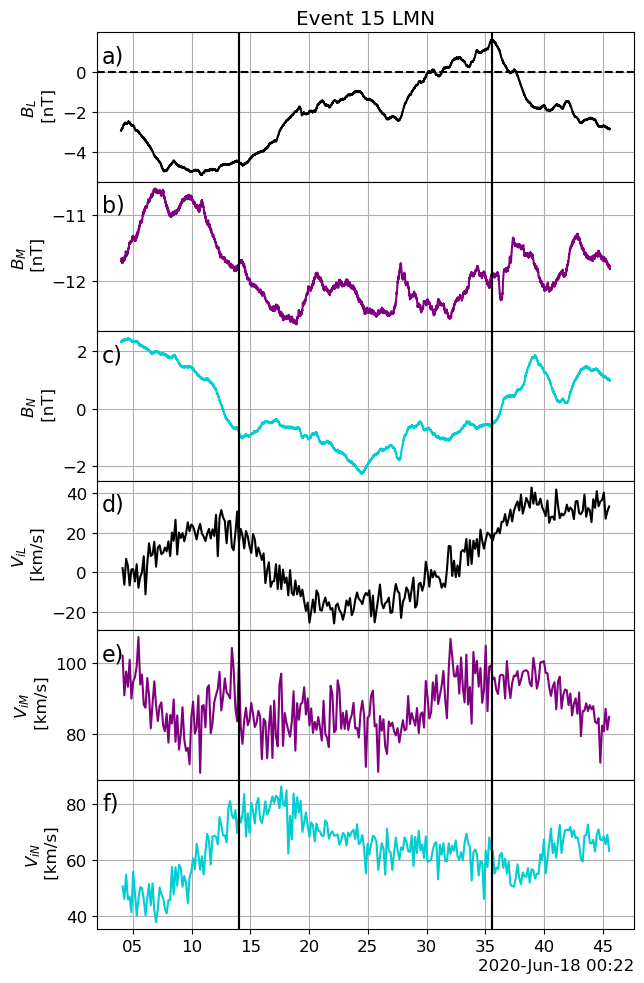

In [277]:
# # add more data to plot
# time1 = pd.to_datetime(m1-dtb)-pd.Timedelta(seconds=1)
# time2 = pd.to_datetime(m2+dtb)+pd.Timedelta(seconds=1)


# st_idx_B2 = MMS_B.date.searchsorted(pd.to_datetime(time1))
# end_idx_B2 = MMS_B.date.searchsorted(pd.to_datetime(time2))

# st_idx_FPI2 = MMS_Vi.date.searchsorted(pd.to_datetime(time1))
# end_idx_FPI2 = MMS_Vi.date.searchsorted(pd.to_datetime(time2))

#%matplotlib inline
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,10))
plt.rcParams.update({'font.size': 12})




ax_BL = fig.add_subplot(611)
ax_BL.set_title(event_num+' LMN')
ax_BL.plot(MMS_B_LMN['date'],MMS_B_LMN['Bl'], color ='black',label='$B_L$')
ax_BL.set_ylabel('$B_L$ \n [nT]')
ax_BL.grid('on')
ax_BL.axhline(y = 0, color = 'k',linestyle='--')
ax_BL.tick_params( axis='x',labelbottom=False)


ax_BM = fig.add_subplot(612,sharex = ax_BL)
ax_BM.plot(MMS_B_LMN['date'],MMS_B_LMN['Bm'], color ='purple',label='$B_M$')
ax_BM.set_ylabel('$B_M$ \n [nT]')
ax_BM.grid('on')
ax_BM.tick_params( axis='x',labelbottom=False)


ax_BN = fig.add_subplot(613,sharex = ax_BL)
ax_BN.plot(MMS_B_LMN['date'],MMS_B_LMN['Bn'], color ='darkturquoise',label='$B_N$')
ax_BN.set_ylabel('$B_N$ \n [nT]')
ax_BN.grid('on')
ax_BN.tick_params( axis='x',labelbottom=False)


ax_VL = fig.add_subplot(614,sharex = ax_BL)
ax_VL.grid('on')
ax_VL.plot(MMS_Vi_LMN['date'],MMS_Vi_LMN['Vil'], color ='black',label='$V_L$')
ax_VL.set_ylabel('$V_{iL}$ \n [km/s]')
ax_VL.grid('on')
ax_VL.tick_params( axis='x',labelbottom=False)

ax_VM = fig.add_subplot(615,sharex = ax_BL)
ax_VM.grid('on')
ax_VM.plot(MMS_Vi_LMN['date'],MMS_Vi_LMN['Vim'], color ='purple',label='$V_M$')
ax_VM.set_ylabel('$V_{iM}$ \n [km/s]')
ax_VM.grid('on')
ax_VM.tick_params( axis='x',labelbottom=False)


ax_VN = fig.add_subplot(616,sharex = ax_BL)
ax_VN.grid('on')
ax_VN.plot(MMS_Vi_LMN['date'],MMS_Vi_LMN['Vin'], color ='darkturquoise',label='$V_N$')
ax_VN.set_ylabel('$V_{iN}$ \n [km/s]')
ax_VN.grid('on')

# ax_walen = fig.add_subplot(616,sharex = ax_B)
# ax_walen.plot(MMS_Vi_LMN['date'],MMS_Vi_LMN['Vil'], color ='black')
# ax_walen.plot(w_walen1['date'],w_walen1['y'], color ='red')
# ax_walen.plot(w_walen2['date'],w_walen2['y'], color ='green')
# ax_walen.set_ylabel('$V_{iL}$ \n [km/s]')
# ax_walen.grid('on')


plt.tight_layout()
plt.subplots_adjust(hspace=0.0)


all_axes = fig.get_axes()

letters = ['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)']

for ax in all_axes:
    ax.grid('on')
    ax.axvline(x = pd.to_datetime(event_st_stop[0]), color = 'green',label='event start')
    ax.axvline(x = pd.to_datetime(event_st_stop[1]), color = 'darkred',label='event end')
    ax.axvline(x = pd.to_datetime(CS_st_stop_t[0]), color = 'k',label='CS start')
    ax.axvline(x = pd.to_datetime(CS_st_stop_t[1]), color = 'k',label='CS end')
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
  
for n, ax in enumerate(all_axes):
    ax.text(0.01,.8,letters[n],transform=ax.transAxes,fontsize=16)

# ax_B.legend(['$B_x$','$B_y$','$B_z$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_BL.legend(['$B_L$','$B_M$','$B_N$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_VL.legend(['$V_{iL}$','$V_{iM}$','$V_{iN}$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_Vi.legend(['$V_{ix}$','$V_{iy}$','$V_{iz}$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_walen.legend(['$V_{iL}$','walén \n analysis'],fontsize='small',loc='center left', bbox_to_anchor=(1, 0.5))

# if save_fig == 'yes':
#     fig.savefig('walen_analysis_' + time_period_string)

# fig.savefig(saveDIR+event_num+'_B_V_LMN')


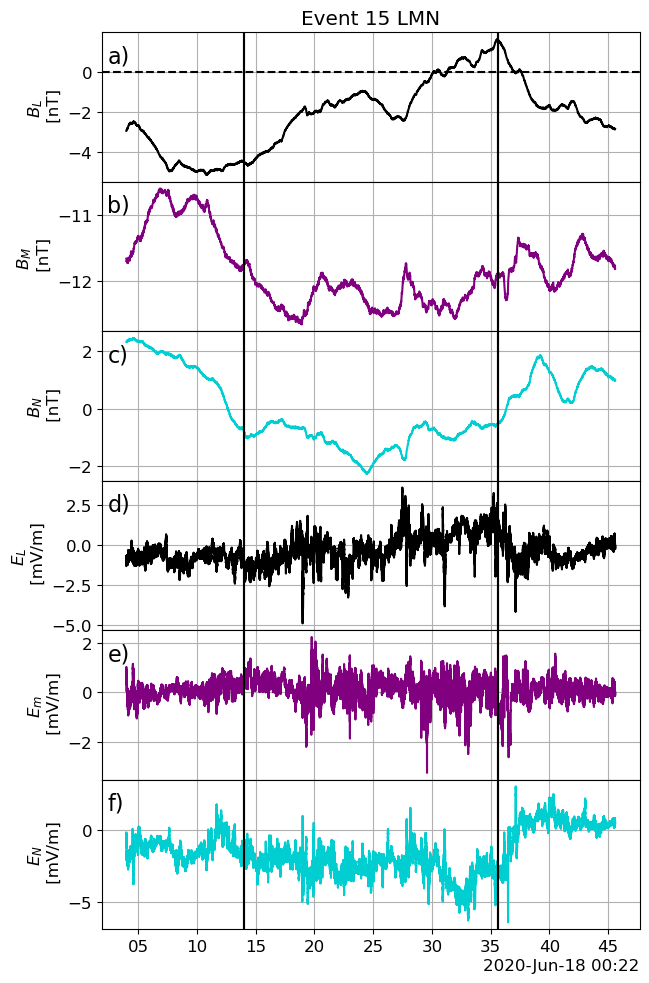

In [278]:
# # add more data to plot
# time1 = pd.to_datetime(m1-dtb)-pd.Timedelta(seconds=1)
# time2 = pd.to_datetime(m2+dtb)+pd.Timedelta(seconds=1)


# st_idx_B2 = MMS_B.date.searchsorted(pd.to_datetime(time1))
# end_idx_B2 = MMS_B.date.searchsorted(pd.to_datetime(time2))

# st_idx_FPI2 = MMS_Vi.date.searchsorted(pd.to_datetime(time1))
# end_idx_FPI2 = MMS_Vi.date.searchsorted(pd.to_datetime(time2))

#%matplotlib inline
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,10))
plt.rcParams.update({'font.size': 12})




ax_BL = fig.add_subplot(611)
ax_BL.set_title(event_num+' LMN')
ax_BL.plot(MMS_B_LMN['date'],MMS_B_LMN['Bl'], color ='black',label='$B_L$')
ax_BL.set_ylabel('$B_L$ \n [nT]')
ax_BL.grid('on')
ax_BL.axhline(y = 0, color = 'k',linestyle='--')
ax_BL.tick_params( axis='x',labelbottom=False)


ax_BM = fig.add_subplot(612,sharex = ax_BL)
ax_BM.plot(MMS_B_LMN['date'],MMS_B_LMN['Bm'], color ='purple',label='$B_M$')
ax_BM.set_ylabel('$B_M$ \n [nT]')
ax_BM.grid('on')
ax_BM.tick_params( axis='x',labelbottom=False)


ax_BN = fig.add_subplot(613,sharex = ax_BL)
ax_BN.plot(MMS_B_LMN['date'],MMS_B_LMN['Bn'], color ='darkturquoise',label='$B_N$')
ax_BN.set_ylabel('$B_N$ \n [nT]')
ax_BN.grid('on')
ax_BN.tick_params( axis='x',labelbottom=False)


ax_EL = fig.add_subplot(614,sharex = ax_BL)
ax_EL.grid('on')
ax_EL.plot(MMS_E_LMN['date'],MMS_E_LMN['El'], color ='black',label='$E_L$')
ax_EL.set_ylabel('$E_L$ \n [mV/m]')
ax_EL.grid('on')
ax_EL.tick_params( axis='x',labelbottom=False)

ax_EM = fig.add_subplot(615,sharex = ax_BL)
ax_EM.grid('on')
ax_EM.plot(MMS_E_LMN['date'],MMS_E_LMN['Em'], color ='purple',label='$E_M$')
ax_EM.set_ylabel('$E_m$ \n [mV/m]')
ax_EM.grid('on')
ax_EM.tick_params( axis='x',labelbottom=False)


ax_EN = fig.add_subplot(616,sharex = ax_BL)
ax_EN.grid('on')
ax_EN.plot(MMS_E_LMN['date'],MMS_E_LMN['En'], color ='darkturquoise',label='$E_N$')
ax_EN.set_ylabel('$E_N$ \n [mV/m]')
ax_EN.grid('on')

# ax_walen = fig.add_subplot(616,sharex = ax_B)
# ax_walen.plot(MMS_Vi_LMN['date'],MMS_Vi_LMN['Vil'], color ='black')
# ax_walen.plot(w_walen1['date'],w_walen1['y'], color ='red')
# ax_walen.plot(w_walen2['date'],w_walen2['y'], color ='green')
# ax_walen.set_ylabel('$V_{iL}$ \n [km/s]')
# ax_walen.grid('on')


plt.tight_layout()
plt.subplots_adjust(hspace=0.0)


all_axes = fig.get_axes()

letters = ['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)']

for ax in all_axes:
    ax.grid('on')
    ax.axvline(x = pd.to_datetime(event_st_stop[0]), color = 'green',label='event start')
    ax.axvline(x = pd.to_datetime(event_st_stop[1]), color = 'darkred',label='event end')
    ax.axvline(x = pd.to_datetime(CS_st_stop_t[0]), color = 'k',label='CS start')
    ax.axvline(x = pd.to_datetime(CS_st_stop_t[1]), color = 'k',label='CS end')
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
  
for n, ax in enumerate(all_axes):
    ax.text(0.01,.8,letters[n],transform=ax.transAxes,fontsize=16)

# ax_B.legend(['$B_x$','$B_y$','$B_z$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_BL.legend(['$B_L$','$B_M$','$B_N$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_VL.legend(['$V_{iL}$','$V_{iM}$','$V_{iN}$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_Vi.legend(['$V_{ix}$','$V_{iy}$','$V_{iz}$'],loc='center left', bbox_to_anchor=(1, 0.5))
# ax_walen.legend(['$V_{iL}$','walén \n analysis'],fontsize='small',loc='center left', bbox_to_anchor=(1, 0.5))

# if save_fig == 'yes':
#     fig.savefig('walen_analysis_' + time_period_string)

# fig.savefig(saveDIR+event_num+'_B_V_LMN')


# Calculate VxB

In [279]:
Vi_vec_LMN = np.zeros((len(MMS_Vi_LMN['Vil']),3))
Vi_vec_LMN[:,0] = np.array(1000*MMS_Vi_LMN['Vil'][0:len(MMS_Vi_LMN['Vil'])])# units in m/s
Vi_vec_LMN[:,1] = np.array(1000*MMS_Vi_LMN['Vim'][0:len(MMS_Vi_LMN['Vim'])])# units in m/s
Vi_vec_LMN[:,2] = np.array(1000*MMS_Vi_LMN['Vin'][0:len(MMS_Vi_LMN['Vin'])])# units in m/s

Ve_vec_LMN = np.zeros((len(MMS_Ve_LMN['Vel']),3))
Ve_vec_LMN[:,0] = np.array(1000*MMS_Ve_LMN['Vel'][0:len(MMS_Ve_LMN['Vel'])])# units in m/s
Ve_vec_LMN[:,1] = np.array(1000*MMS_Ve_LMN['Vem'][0:len(MMS_Ve_LMN['Vem'])])# units in m/s
Ve_vec_LMN[:,2] = np.array(1000*MMS_Ve_LMN['Ven'][0:len(MMS_Ve_LMN['Ven'])])# units in m/s


# interpolate B down to Vi cadence
b_ind_vi_LMN = MMS_B_LMN.date.searchsorted(MMS_Vi_LMN['date'])
b_ind_vi_LMN = b_ind_vi_LMN[0:len(b_ind_vi_LMN)-1]
B_vec_vi_LMN = np.zeros((len(b_ind_vi_LMN),3))

B_vec_vi_LMN = np.zeros((len(b_ind_vi_LMN),3))
B_vec_vi_LMN[:,0] = np.array(1e-9*MMS_B_LMN['Bl'][b_ind_vi_LMN])# units in T (1 kg⋅s−2⋅A−1)
B_vec_vi_LMN[:,1] = np.array(1e-9*MMS_B_LMN['Bm'][b_ind_vi_LMN])# units in T (1 kg⋅s−2⋅A−1)
B_vec_vi_LMN[:,2] = np.array(1e-9*MMS_B_LMN['Bn'][b_ind_vi_LMN])# units in T (1 kg⋅s−2⋅A−1)


# interpolate B down to Ve cadence
b_ind_ve_LMN = MMS_B_LMN.date.searchsorted(MMS_Ve_LMN['date'])
b_ind_ve_LMN = b_ind_ve_LMN[0:len(b_ind_ve_LMN)-1]
B_vec_ve_LMN = np.zeros((len(b_ind_ve_LMN),3))

B_vec_ve_LMN = np.zeros((len(b_ind_ve_LMN),3))
B_vec_ve_LMN[:,0] = np.array(1e-9*MMS_B_LMN['Bl'][b_ind_ve_LMN])# units in T (1 kg⋅s−2⋅A−1)
B_vec_ve_LMN[:,1] = np.array(1e-9*MMS_B_LMN['Bm'][b_ind_ve_LMN])# units in T (1 kg⋅s−2⋅A−1)
B_vec_ve_LMN[:,2] = np.array(1e-9*MMS_B_LMN['Bn'][b_ind_ve_LMN])# units in T (1 kg⋅s−2⋅A−1)

VixB_LMN = np.zeros((len(B_vec_vi_LMN),3))

# 0th column will be x-component, 1st column will be y-comp, and 2nd column will be z-comp of cross product
for i in range(len(B_vec_vi_LMN)):
    VixB_LMN[i,:]= 1000* np.cross(Vi_vec_LMN[i,:],B_vec_vi_LMN[i,:]) # units in mV /m (Millivolt per meter)


VexB_LMN = np.zeros((len(B_vec_ve_LMN),3))

# 0th column will be x-component, 1st column will be y-comp, and 2nd column will be z-comp of cross product
for i in range(len(B_vec_ve_LMN)):
    VexB_LMN[i,:]= 1000* np.cross(Ve_vec_LMN[i,:],B_vec_ve_LMN[i,:])# units in mV /m (Millivolt per meter)

VixB_LMN = pd.DataFrame({"date": MMS_Vi_LMN['date'][0:len(MMS_Vi_LMN['date'])-1], "VixB_LMN_l": -VixB_LMN[:,0],"VixB_LMN_m": -VixB_LMN[:,1],
                     "VixB_LMN_n": -VixB_LMN[:,2]})

VexB_LMN = pd.DataFrame({"date": MMS_Ve_LMN['date'][0:len(MMS_Ve_LMN['date'])-1], "VexB_LMN_l": -VexB_LMN[:,0],"VexB_LMN_m": -VexB_LMN[:,1],
                     "VexB_LMN_n": -VexB_LMN[:,2]})
# VixB_LMN = pd.DataFrame({"date": MMS_Vi_LMN['date'][0:len(MMS_Vi_LMN['date'])-1], "VixB_LMN_l": VixB_LMN[:,0],"VixB_LMN_m": VixB_LMN[:,1],
#                      "VixB_LMN_n": VixB_LMN[:,2]})

# VexB_LMN = pd.DataFrame({"date": MMS_Ve_LMN['date'][0:len(MMS_Ve_LMN['date'])-1], "VexB_LMN_l": VexB_LMN[:,0],"VexB_LMN_m": VexB_LMN[:,1],
#                      "VexB_LMN_n": VexB_LMN[:,2]})

# smooth VxB data

In [280]:
# 2. Define the window size for smoothing
window_size_ve = 10 # Adjust this value to control the amount of smoothing
window_size_E = 1000
# 3. Create the boxcar kernel
# The kernel is an array of ones, normalized by the window size
boxcar_kernel_ve = np.ones(window_size_ve) / window_size_ve
boxcar_kernel_E = np.ones(window_size_E) / window_size_E

# 4. Apply convolution for smoothing
# 'same' mode ensures the output array has the same length as the input


smoothed_MMS_El = np.convolve(MMS_E_LMN['El'][MMS_E_LMN.date.searchsorted(m1 - dtb):MMS_E_LMN.date.searchsorted(m2 + dta)], boxcar_kernel_E, mode='same')
smoothed_MMS_Em = np.convolve(MMS_E_LMN['Em'][MMS_E_LMN.date.searchsorted(m1 - dtb):MMS_E_LMN.date.searchsorted(m2 + dta)], boxcar_kernel_E, mode='same')
smoothed_MMS_En = np.convolve(MMS_E_LMN['En'][MMS_E_LMN.date.searchsorted(m1 - dtb):MMS_E_LMN.date.searchsorted(m2 + dta)], boxcar_kernel_E, mode='same')

smoothed_VexB_l = np.convolve(VexB_LMN['VexB_LMN_l'][VexB_LMN.date.searchsorted(m1 - dtb):VexB_LMN.date.searchsorted(m2 + dta)], boxcar_kernel_ve, mode='same')
smoothed_VexB_m = np.convolve(VexB_LMN['VexB_LMN_m'][VexB_LMN.date.searchsorted(m1 - dtb):VexB_LMN.date.searchsorted(m2 + dta)], boxcar_kernel_ve, mode='same')
smoothed_VexB_n = np.convolve(VexB_LMN['VexB_LMN_n'][VexB_LMN.date.searchsorted(m1 - dtb):VexB_LMN.date.searchsorted(m2 + dta)], boxcar_kernel_ve, mode='same')


# Generate LMN and VxB plots

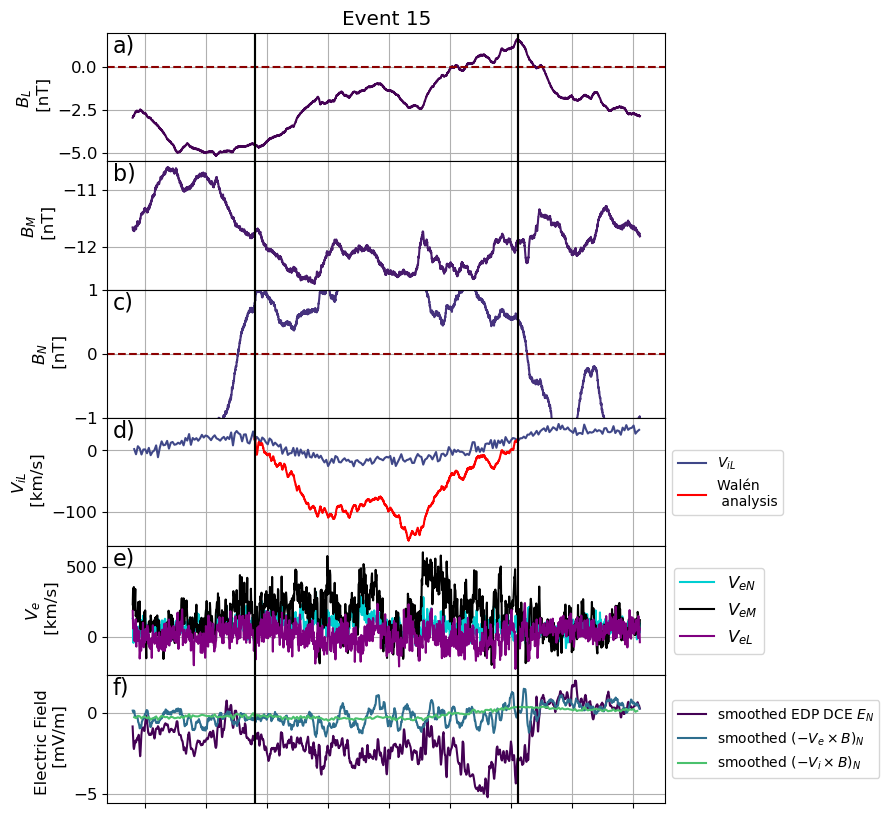

In [281]:

from matplotlib.colors import ListedColormap


mag_arr_str = [MMS_B_LMN]
vi_arr_str = [MMS_Vi_LMN]
ve_arr_str = [MMS_Ve_LMN]
E_arr_str = [MMS_E_LMN]

# Choose a colormap (e.g., 'viridis')
cmap = plt.get_cmap('viridis')

# Create a ListedColormap with the first 10 colors
num_colors = 15

colors = ListedColormap(cmap(np.linspace(0, 1, num_colors))).colors
plt.rcParams.update({'font.size': 12})

i=0
fig = plt.figure(figsize=(8,10))
ax_BL = fig.add_subplot(6,1,1)
ax_BL.set_title(event_num)
ax_BL.plot(mag_arr_str[i]['date'],mag_arr_str[i]['Bl'], color =colors[0])
ax_BL.set_ylabel('$B_L$ \n [nT]')
ax_BL.tick_params( axis='x',labelbottom=False)
ax_BL.axhline(y = 0, color = 'darkred', linestyle='--')

ax_BM = fig.add_subplot(6,1,2,sharex = ax_BL)
ax_BM.plot(mag_arr_str[i]['date'],mag_arr_str[i]['Bm'], color =colors[1])
ax_BM.set_ylabel('$B_M$ \n [nT]')
ax_BM.tick_params(axis='x',labelbottom=False)
#ax_BM.set_ylim([8,15])

ax_BN = fig.add_subplot(6,1,3,sharex = ax_BL)
ax_BN.plot(mag_arr_str[i]['date'],-mag_arr_str[i]['Bn'], color =colors[2])
ax_BN.set_ylabel('$B_N$ \n [nT]')
ax_BN.tick_params( axis='x',labelbottom=False)
ax_BN.axhline(y = 0, color = 'darkred', linestyle='--')
ax_BN.set_ylim([-1,1])


# only show walen predictions at start and stop of CS
st_idx_w = w_walen1.date.searchsorted(pd.to_datetime(CS_st_stop_t[0]))
end_idx_w = w_walen2.date.searchsorted(pd.to_datetime(CS_st_stop_t[1]))
ax_ViL = fig.add_subplot(6,1,4,sharex = ax_BL)
ax_ViL.grid('on')
lineab = ax_ViL.plot(vi_arr_str[i]['date'],vi_arr_str[i]['Vil'], color =colors[3])
linecd = ax_ViL.plot(w_walen1['date'][st_idx_w:len(w_walen1['date'])-1],w_walen1['y'][st_idx_w:len(w_walen1['date'])-1], color ='red')
ax_ViL.plot(w_walen2['date'][0:end_idx_w],w_walen2['y'][0:end_idx_w], color ='red')
ax_ViL.set_ylabel('$V_{iL}$ \n [km/s]')
ax_ViL.tick_params( axis='x',labelbottom=False)



ax_Ve = fig.add_subplot(6,1,5,sharex = ax_BL)
ax_Ve.plot(ve_arr_str[i]['date'],ve_arr_str[i]['Ven'], color ='darkturquoise')
ax_Ve.plot(ve_arr_str[i]['date'],ve_arr_str[i]['Vem'], color ='black')
ax_Ve.plot(ve_arr_str[i]['date'],ve_arr_str[i]['Vel'], color ='purple')
ax_Ve.set_ylabel('$V_{e}$ \n [km/s]')
ax_Ve.tick_params( axis='x',labelbottom=False)


ax7 = fig.add_subplot(6,1,6)
# line7, = ax7.plot(MMS_E_LMN['date'][MMS_E_LMN.date.searchsorted(m1 - dtb):MMS_E_LMN.date.searchsorted(m2 + dta)],
#           smoothed_MMS_En,
#           label =['smoothed EDP DCB $E_N$'], color = colors[0])

# line8, = ax7.plot(VexB_LMN['date'][VexB_LMN.date.searchsorted(m1 - dtb):VexB_LMN.date.searchsorted(m2 + dta)],
#              smoothed_VexB_n,
#                   label =[r'smoothed $(-V_e \times B)_N$'],color = colors[5])
# line9, = ax7.plot(VixB_LMN['date'][VixB_LMN.date.searchsorted(m1 - dtb):VixB_LMN.date.searchsorted(m2 + dta)],
#              VixB_LMN['VixB_LMN_n'][VixB_LMN.date.searchsorted(m1 - dtb):VixB_LMN.date.searchsorted(m2 + dta)],
#                   label =[r'smoothed $(-V_i \times B)_L$'],color = colors[10])

line7, = ax7.plot(MMS_E_LMN['date'],smoothed_MMS_En,label =['smoothed EDP DCB $E_N$'], color = colors[0])
line8, = ax7.plot(VexB_LMN['date'],smoothed_VexB_n,label =[r'smoothed $(-V_e \times B)_N$'],color = colors[5])
line9, = ax7.plot(VixB_LMN['date'],VixB_LMN['VixB_LMN_n'],label =[r'smoothed $(-V_i \times B)_L$'],color = colors[10])
ax7.set_ylabel('Electric Field \n [mV/m]')
ax7.tick_params( axis='x',labelbottom=False)




plt.subplots_adjust(hspace=0.0)




all_axes = fig.get_axes()

letters = ['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)']

for ax in all_axes:
    ax.grid('on')
    ax.axvline(x = pd.to_datetime(event_st_stop[0]), color = 'green',label='event start')
    ax.axvline(x = pd.to_datetime(event_st_stop[1]), color = 'darkred',label='event end')
    ax.axvline(x = pd.to_datetime(CS_st_stop_t[0]), color = 'k',label='CS start')
    ax.axvline(x = pd.to_datetime(CS_st_stop_t[1]), color = 'k',label='CS end')
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.9, box.height])

for n, ax in enumerate(all_axes):
    ax.text(0.01,.85,letters[n],transform=ax.transAxes,fontsize=16)


ax_ViL.legend(labels=['$V_{iL}$','Walén \n analysis'],fontsize='small',loc='center left', bbox_to_anchor=(1, 0.5))
ax_Ve.legend(labels=['$V_{eN}$','$V_{eM}$','$V_{eL}$'],loc='center left', bbox_to_anchor=(1, 0.5))
ax7.legend(handles=[line7,line8,line9],fontsize='small',labels=['smoothed EDP DCE $E_N$',r'smoothed $(-V_e \times B)_N$',r'smoothed $(-V_i \times B)_N$'],
           loc='center left', bbox_to_anchor=(1, 0.5))

#fig.savefig(saveDIR+event_num+'_Walen_analysis_smoothed_E_field_vs_VixB_VexB')


